# 07: Spatial barcode-transfer distance

Every cancer clone carries a unique lentiviral **barcode**. The barcode RNA does
not stay put — it is picked up by nearby cells, so a non-cancer cell next to a
barcoded cancer cell can end up reading that same barcode. This notebook measures
**how far a barcode travels from its cancer cell of origin**.

For each clone the barcode-positive cells split into **sender cells** (cancer) and
**receiver cells** (non-cancer); for every receiver we take the distance to the
nearest sender of the same clone. Two views follow:

* **Transfer probability** `g(r)` — of the non-cancer cells at distance `r` from a
  source, the fraction that carry the barcode (geometry-normalised, so it is a
  clean per-cell probability). It decays exponentially with distance.
* **Receiver spread** — how far the receivers that exist sit, decile by decile.

**Inputs** (place under `data/`, relative paths):
* `data/visium_{sample}_cells_final.h5ad` — segmented cells: `cell_id`,
  `obsm['spatial_fullres']` (centroids, full-res pixels), `obs['cell_type']`.
* `data/cell_barcode_{sample}.npz` — cell × barcode matrix (`cells`, `barcodes`,
  CSR `data/indices/indptr/shape`).


In [1]:
import numpy as np, pandas as pd, scipy.sparse as sp, anndata as ad
from pathlib import Path
from scipy.optimize import curve_fit
from scipy.spatial import cKDTree
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt

DATA = Path('data') if Path('data').exists() else Path('../data')   # repo-root or notebooks/
SAMPLES = ['1RR']
MPP = {'1RR': 0.7600241753442841}   # µm per full-res pixel
R_MAX, N_BINS = 400.0, 20                # decay window / distance bins (µm)
DBSCAN_EPS, DBSCAN_MIN = 80.0, 3         # drop isolated single-read barcode calls
TOP_N = 150                             # clones with the most receivers, for g(r)
SAMPLE_COLORS = {'1RR': '#0072B2'}
FIT, NULL = '#D6604D', '#999999'
plt.rcParams.update({'font.family': 'DejaVu Sans', 'font.size': 12,
                     'axes.titlesize': 14, 'axes.labelsize': 12, 'xtick.labelsize': 10,
                     'ytick.labelsize': 10, 'legend.fontsize': 10, 'figure.titlesize': 15,
                     'axes.titleweight': 'normal', 'axes.spines.top': False,
                     'axes.spines.right': False, 'figure.facecolor': 'white',
                     'axes.facecolor': 'white'})
print('setup done')


setup done


## How `cell_barcode_{sample}.npz` is produced

The barcode table is built once by aggregating the raw 2 µm-bin barcode counts up
to segmented cells (bin → cell mapping from `barcode_mappings.parquet`). The
function below is the exact producer; it is skipped when the `.npz` is already
present, so **Run-All uses the provided file** and does not touch the multi-GB bin
matrices.


In [2]:
def build_cell_barcode_npz(sample):
    out = DATA / f'cell_barcode_{sample}.npz'
    if out.exists():
        return out                                   # provided -> nothing to do
    binh5 = ad.read_h5ad(DATA / f'visiumHD/{sample}/{sample}_square_002um.h5ad')
    labels_1read = binh5.obsm['labels_1read']        # (n_bins, n_barcodes), CSR
    barcodes = np.asarray(binh5.uns['labels_1read'])
    mp = pd.read_parquet(DATA / f'visiumHD/{sample}/barcode_mappings.parquet')
    mp = mp[mp.in_cell & mp.cell_id.notna()]
    cells, cell_idx = np.unique(mp.cell_id.values, return_inverse=True)
    cell_x_bin = sp.csr_matrix((np.ones(len(mp)), (cell_idx, mp.square_002um.values)),
                               shape=(len(cells), labels_1read.shape[0]))
    M = (cell_x_bin @ labels_1read).tocsr().astype('int32')     # cells × barcodes
    np.savez_compressed(out, cells=cells, barcodes=barcodes,
                        data=M.data, indices=M.indices, indptr=M.indptr, shape=M.shape)
    return out

for s in SAMPLES:
    build_cell_barcode_npz(s)      # no-op when the npz is provided
print('barcode tables ready')


barcode tables ready


## Load each sample

Everything the analysis needs is derived from the two input files: per-cell **µm
coordinates** (`spatial_fullres` × µm-per-pixel), the **cancer / non-cancer** call
(`cell_type == 'cancer'`), and the **cell × barcode** matrix — all aligned by
`cell_id`.


In [3]:
def load(sample):
    a = ad.read_h5ad(DATA / f'visium_{sample}_cells_final.h5ad', backed='r')
    cid = a.obs['cell_id'].astype(str).values
    xy_px = np.asarray(a.obsm['spatial_fullres'], dtype=float)
    is_cancer_all = a.obs['cell_type'].astype(str).values == 'cancer'
    a.file.close()

    z = np.load(DATA / f'cell_barcode_{sample}.npz', allow_pickle=True)
    M = sp.csr_matrix((z['data'], z['indices'], z['indptr']), shape=tuple(z['shape']))
    bc_cells = z['cells'].astype(str)
    barcodes = z['barcodes'].astype(str)

    pos = {c: i for i, c in enumerate(cid)}                     # align barcode rows -> h5ad
    rows = np.fromiter((pos.get(c, -1) for c in bc_cells), dtype=np.int64, count=len(bc_cells))
    ok = rows >= 0
    coords = xy_px[rows[ok]] * MPP[sample]                      # µm
    is_cancer = is_cancer_all[rows[ok]]
    M = M[ok]
    # per-barcode sender/receiver counts (for picking the biggest clones)
    Mb = (M > 0)
    n_send = np.asarray(Mb[is_cancer].sum(0)).ravel()
    n_recv = np.asarray(Mb[~is_cancer].sum(0)).ravel()
    return dict(coords=coords, is_cancer=is_cancer, M=M.tocsc(),
                barcodes=barcodes, n_send=n_send, n_recv=n_recv)

DATASETS = {s: load(s) for s in SAMPLES}
for s in SAMPLES:
    D = DATASETS[s]
    print(f"{s}: {len(D['coords']):,} cells  ·  {int(D['is_cancer'].sum()):,} cancer  ·  "
          f"{D['M'].shape[1]:,} barcodes")


1RR: 211,963 cells  ·  59,033 cancer  ·  16,999 barcodes


In [4]:
def clone_cells(D, col):
    """Sender (cancer) and receiver (non-cancer) cell indices for barcode column
    `col`, after a DBSCAN pass that drops isolated single-read calls."""
    rows = D['M'].getcol(col).nonzero()[0]
    if rows.size < 8:
        return None, None
    lab = DBSCAN(eps=DBSCAN_EPS, min_samples=DBSCAN_MIN).fit_predict(D['coords'][rows])
    keep = lab >= 0
    src = rows[keep & D['is_cancer'][rows]]
    rec = rows[keep & ~D['is_cancer'][rows]]
    return src, rec

def top_clone_cols(D, k, min_send=3, min_recv=5):
    elig = np.where((D['n_send'] >= min_send) & (D['n_recv'] >= min_recv))[0]
    return elig[np.argsort(D['n_recv'][elig])[::-1][:k]]


## Barcode transfer probability vs distance

For the 150 clones with the most receivers, bin all non-cancer cells by distance to
the nearest sender and take the fraction carrying the barcode in each bin — that is
`g(r)`. Averaged across clones (bootstrap 95 % CI) and fit with
`g(r) = A·e^(−r/λ) + c`. The **shuffled null** relabels the same number of receivers
at random and is essentially flat, so the decay is real. We report the half-distance
`λ·ln 2` (where the probability halves).


1RR: lambda = 63.8 um  (half-distance 44.2 um)  ·  145 clones


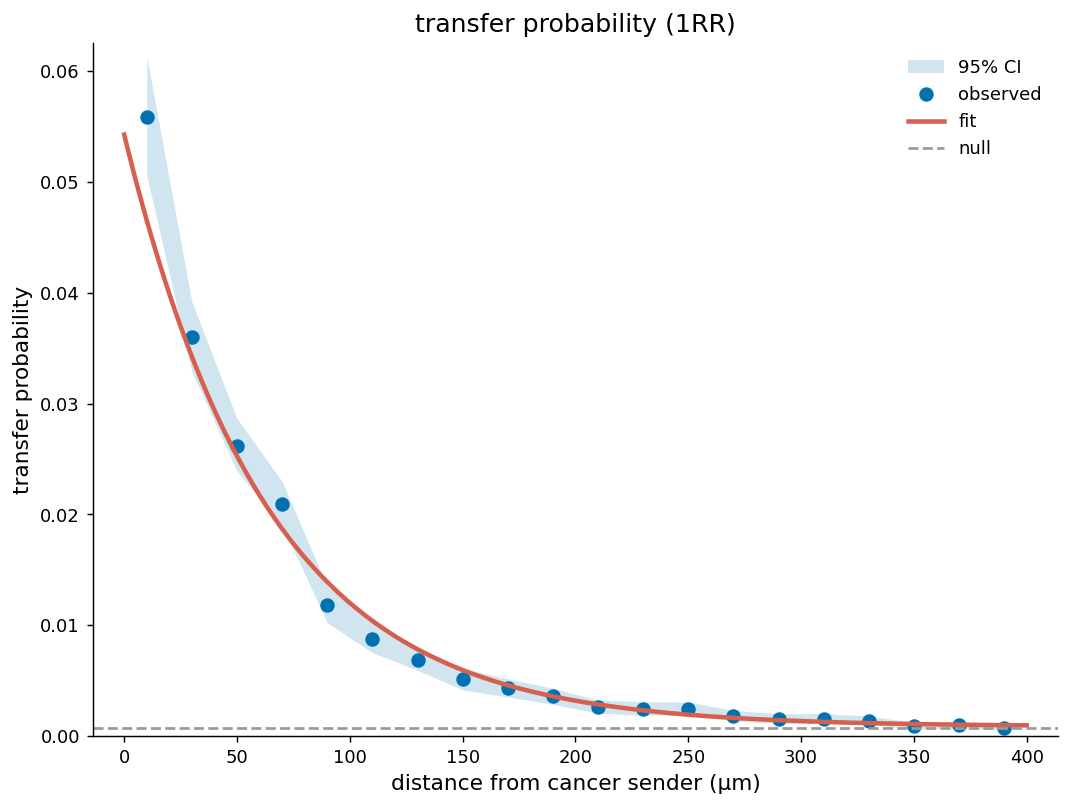

In [5]:
def decay_exp(r, A, lam, c):
    return A * np.exp(-r / lam) + c

def fit_decay(D):
    cols = top_clone_cols(D, TOP_N)
    noncancer = np.where(~D['is_cancer'])[0]
    nc_coords = D['coords'][noncancer]
    nc_pos = {m: i for i, m in enumerate(noncancer)}
    edges = np.linspace(0, R_MAX, N_BINS + 1)
    centers = 0.5 * (edges[:-1] + edges[1:])
    rng = np.random.default_rng(0)
    rows_P, null_acc = [], []
    for col in cols:
        src, rec = clone_cells(D, col)
        if src is None or src.size < 3 or rec.size < 5:
            continue
        d_nc, _ = cKDTree(D['coords'][src]).query(nc_coords, k=1)
        which = np.clip(np.digitize(d_nc, edges) - 1, 0, N_BINS - 1)
        win = d_nc <= R_MAX
        tot = np.bincount(which[win], minlength=N_BINS).astype(float)
        rec_nc = np.array([nc_pos[m] for m in rec if m in nc_pos])
        is_rec = np.zeros(noncancer.size, bool); is_rec[rec_nc] = True
        with np.errstate(divide='ignore', invalid='ignore'):
            rows_P.append(np.where(tot > 0, np.bincount(which[win & is_rec], minlength=N_BINS) / tot, np.nan))
        perm = np.zeros(noncancer.size, bool)
        perm[rng.choice(noncancer.size, rec_nc.size, replace=False)] = True
        null_acc.append(np.where(tot > 0, np.bincount(which[win & perm], minlength=N_BINS) / tot, np.nan))
    P = np.vstack(rows_P); base = float(np.nanmean(np.vstack(null_acc)))
    mean = np.nanmean(P, axis=0)
    boots = np.array([np.nanmean(P[rng.integers(0, len(P), len(P))], 0) for _ in range(1000)])
    lo, hi = np.nanpercentile(boots, [2.5, 97.5], axis=0)
    ok = np.isfinite(mean) & (mean > 0)
    lm = lambda r, A, lam, c: np.log10(decay_exp(r, A, lam, c))
    f1 = lambda x, y: curve_fit(lm, x, np.log10(y), p0=[mean[ok][0], 80, base],
                                bounds=([0, 5, base * 0.2], [1, 1000, max(base * 3, 1e-6)]),
                                maxfev=20000)[0]
    A, lam, c = f1(centers[ok], mean[ok])
    lams = []
    for _ in range(500):
        m = np.nanmean(P[rng.integers(0, len(P), len(P))], 0); k = np.isfinite(m) & (m > 0)
        if k.sum() >= 4:
            try: lams.append(f1(centers[k], m[k])[1])
            except Exception: pass
    l_lo, l_hi = np.percentile(lams, [2.5, 97.5]) if lams else (np.nan, np.nan)
    return dict(centers=centers, mean=mean, lo=lo, hi=hi, base=base, A=A, lam=lam, c=c,
                l_lo=l_lo, l_hi=l_hi, n=len(P))

FITS = {s: fit_decay(DATASETS[s]) for s in SAMPLES}

fig, axes = plt.subplots(1, len(SAMPLES), figsize=(8.3 * len(SAMPLES), 6.4), squeeze=False)
for ax, s in zip(axes.ravel(), SAMPLES):
    f = FITS[s]; col = SAMPLE_COLORS[s]
    ax.fill_between(f['centers'], f['lo'], f['hi'], color=col, alpha=0.18, lw=0, label='95% CI')
    ax.plot(f['centers'], f['mean'], 'o', color=col, ms=7, label='observed')
    rr = np.linspace(0, R_MAX, 200)
    ax.plot(rr, decay_exp(rr, f['A'], f['lam'], f['c']), '-', color=FIT, lw=2.5, label='fit')
    ax.axhline(f['base'], color=NULL, ls='--', lw=1.5, label='null')
    ax.set_xlim(-14, R_MAX + 14); ax.set_ylim(0, np.nanmax(f['mean']) * 1.12)
    ax.set_xlabel('distance from cancer sender (µm)'); ax.set_ylabel('transfer probability')
    ax.set_title(f'transfer probability ({s})'); ax.legend(frameon=False, loc='upper right')
fig.tight_layout(); fig.subplots_adjust(wspace=0.24, left=0.08, right=0.975)
for s in SAMPLES:
    f = FITS[s]
    print(f"{s}: lambda = {f['lam']:.1f} um  (half-distance {f['lam']*np.log(2):.1f} um)  ·  {f['n']} clones")


## How far the barcoded receivers actually sit

The complementary view: across clones, the 10th–90th percentile of each clone's
receiver-to-nearest-sender distance. The median rises smoothly with percentile and
follows the quantile function of an exponential spread, `d(p) = d0 − λ·ln(1 − p)`.
`λ` here exceeds the per-cell probability's because more tissue (more candidate
cells) lies farther out.


1RR: lambda = 98.5 um  ·  488 clones


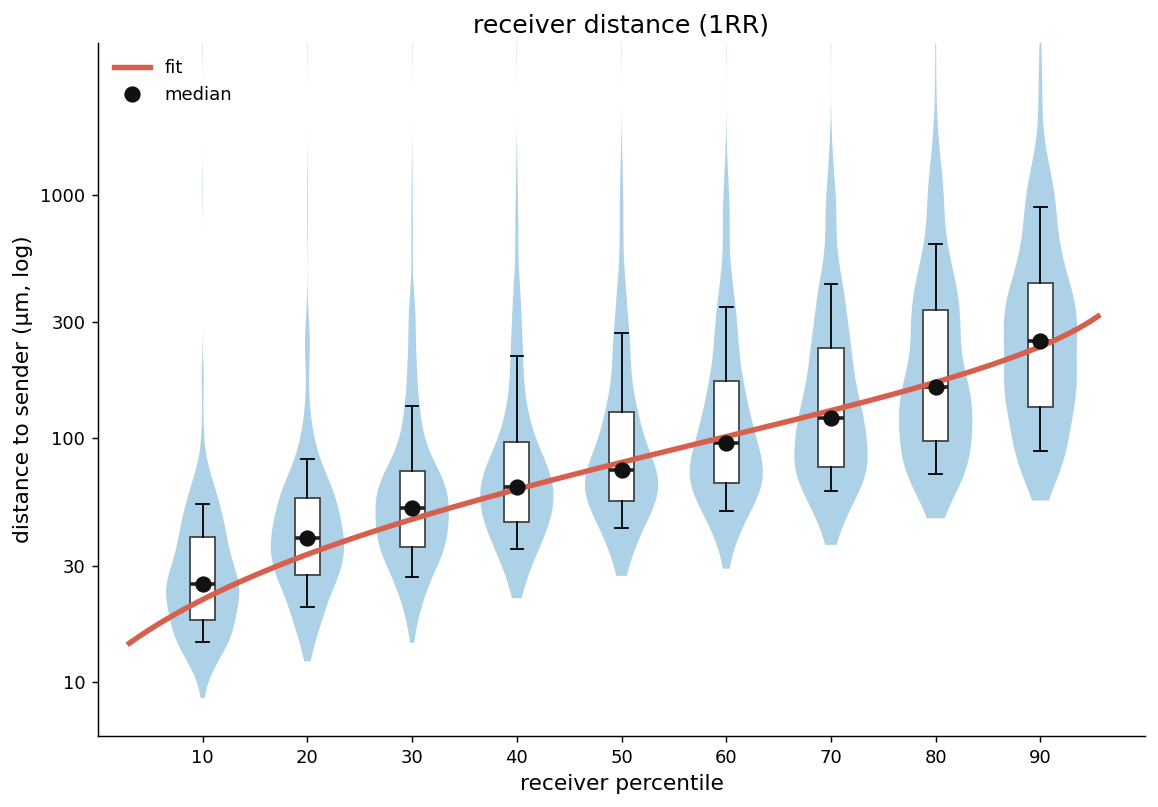

In [6]:
DECILES = np.arange(10, 100, 10)

def clone_deciles(D):
    rows = []
    for col in np.where((D['n_send'] >= 3) & (D['n_recv'] >= 10))[0]:
        src, rec = clone_cells(D, col)
        if src is None or src.size < 3 or rec.size < 10:
            continue
        d, _ = cKDTree(D['coords'][src]).query(D['coords'][rec], k=1)
        rows.append(np.percentile(d, DECILES))
    return np.array(rows)

def quantile_exp(p, lam, d0):
    return d0 - lam * np.log(1.0 - p)

fig, axes = plt.subplots(1, len(SAMPLES), figsize=(9 * len(SAMPLES), 6.4), squeeze=False)
for ax, s in zip(axes.ravel(), SAMPLES):
    Q = clone_deciles(DATASETS[s]); col = SAMPLE_COLORS[s]
    data = [np.clip(Q[:, i][np.isfinite(Q[:, i])], 1, None) for i in range(len(DECILES))]
    med = np.array([np.median(d) for d in data]); pp = DECILES / 100.0
    lam, d0 = curve_fit(quantile_exp, pp, med, p0=[80, 10],
                        bounds=([1, -200], [2000, 500]), maxfev=20000)[0]
    lg = np.log10                                   # log y-axis (matches the paper)
    for b in ax.violinplot([lg(d) for d in data], positions=DECILES.astype(float),
                           widths=7.0, showextrema=False)['bodies']:
        b.set_facecolor(col); b.set_alpha(0.32); b.set_edgecolor('none')
    bp = ax.boxplot([lg(d) for d in data], positions=DECILES.astype(float), widths=2.4,
                    showfliers=False, whis=(10, 90), patch_artist=True,
                    medianprops=dict(color='#222', lw=2), manage_ticks=False)
    for patch in bp['boxes']:
        patch.set_facecolor('white'); patch.set_edgecolor('#444')
    rr = np.linspace(0.03, 0.955, 300)
    ax.plot(rr * 100, lg(quantile_exp(rr, lam, d0)), '-', color=FIT, lw=3, zorder=5, label='fit')
    ax.plot(DECILES, lg(med), 'o', color='#111', ms=8, zorder=6, label='median')
    yt = np.array([10, 30, 100, 300, 1000])
    ax.set_yticks(np.log10(yt)); ax.set_yticklabels([str(v) for v in yt])
    ax.set_ylim(np.log10(6), np.log10(4200))
    ax.set_xticks(DECILES); ax.set_xticklabels([str(p) for p in DECILES]); ax.set_xlim(0, 100)
    ax.set_xlabel('receiver percentile'); ax.set_ylabel('distance to sender (µm, log)')
    ax.set_title(f'receiver distance ({s})'); ax.legend(frameon=False, loc='upper left')
    print(f'{s}: lambda = {lam:.1f} um  ·  {len(Q)} clones')
fig.tight_layout(); fig.subplots_adjust(wspace=0.22, left=0.08, right=0.975)


## Representative clones in space

Four representative clones on the tissue, rendered with the **data-viewer app's
default settings** (10 µm KDE grid, 100 µm bandwidth, level-set contour at
0.20 × peak density — `viewer/static/contours.html`). Cells are drawn as their real
segmentation polygons, tinted by cell type; the clone's barcode-positive cells are
split into **sender cells (cancer, red)** and **receiver cells (non-cancer, blue)**,
each sized by its label-UMI count. Two smooth level-set contours mark the clone —
a blue contour over all barcode-positive cells and a red contour over senders only,
estimated on the same grid and cut at the same absolute threshold. The corner inset
locates the clone's barcode-positive cells within the whole section.

**Extra inputs** for this panel (same data-viewer assets used for the paper figure):
`viewer/static/contour_data/` (per-cell coordinates + palette + per-clone
barcode-positive cell lists), `analysis/results/obj2/barcode_contours_{sample}.csv`
(per-clone contour statistics) and `figures/pubfigs/_cache/segpolys_{sample}.npz`
(cached segmentation polygons).


In [7]:
import json
from scipy.ndimage import gaussian_filter, label as ndlabel
from matplotlib.lines import Line2D
from matplotlib.patches import Patch, Rectangle
from matplotlib.collections import PolyCollection

# repo-relative roots (the data-viewer assets ship alongside the notebook inputs).
# DATA may be a symlink to bulk storage, so anchor on its parent WITHOUT resolving it.
PROJECT = DATA.parent
CD     = PROJECT / 'viewer' / 'static' / 'contour_data'    # cells.bin, palette, barcode_pos
RES    = PROJECT / 'analysis' / 'results' / 'obj2'          # per-clone contour table
PUBFIG = PROJECT / 'figures' / 'pubfigs'                    # segmentation-polygon cache + output

# colours + KDE parameters mirror the interactive data-viewer (contours.html) defaults
OUTER_LINE = '#2f8fd0'                       # all-barcode+ contour  (viewer cyan [94,200,255])
SENDER_LINE = '#d81e4a'                      # sender-only contour   (viewer red  [230,25,75])
SENDER_DOT, RECEIVER_DOT = '#c81e3a', '#1f52d8'   # sender = red, receiver = blue
DOT_BASE = 46.0                              # scatter area per label-UMI
BIN_UM, SIGMA_UM, LEVEL = 10.0, 100.0, 0.20  # viewer defaults: grid / bandwidth / level

def _pastel(hexcol, frac=0.58):
    h = hexcol.lstrip('#'); r, g, b = (int(h[i:i+2], 16) for i in (0, 2, 4))
    r, g, b = (int(v + (255 - v) * frac) for v in (r, g, b))
    return f'#{r:02x}{g:02x}{b:02x}'

def _load(sample):
    gm = json.loads((CD / 'meta.json').read_text())
    pal, vocab = dict(gm['palette']), list(gm['cell_type_vocab'])
    vocab = ['osteoclast-like' if v == 'chemokine' else v for v in vocab]   # project rename
    if 'chemokine' in pal:
        pal['osteoclast-like'] = pal['chemokine']
    sm = json.loads((CD / f'{sample}_meta.json').read_text())
    n, mpp, lq = sm['n_cells'], sm['mpp'], sm['lq_idx']
    raw = (CD / f'{sample}_cells.bin').read_bytes()
    x = np.frombuffer(raw[:4 * n], '<f4').astype(np.float64) * mpp
    y = np.frombuffer(raw[4 * n:8 * n], '<f4').astype(np.float64) * mpp
    ct = np.frombuffer(raw[8 * n:9 * n], 'u1')
    return x, y, ct, pal, vocab, lq, sm['cancer_idx']

_SEG = {}
def _segpolys(sample):
    if sample not in _SEG:
        z = np.load(PUBFIG / '_cache' / f'segpolys_{sample}.npz')
        _SEG[sample] = (z['verts'], z['offsets'])
    return _SEG[sample]

def _kde(px, py, cnt, frame):
    # density on a FIXED grid frame, so any subset is point-wise comparable
    fx0, fx1, fy0, fy1, nx, ny = frame
    H, _, _ = np.histogram2d(px, py, bins=[nx, ny], range=[[fx0, fx1], [fy0, fy1]], weights=cnt)
    return gaussian_filter(H, sigma=SIGMA_UM / BIN_UM, mode='constant')
print('exemplar helpers ready')


exemplar helpers ready


In [8]:
def clone_geometry(sample, idx, pad_um=90.0, senders=True):
    # KDE, main-blob crop and containment for one clone
    x, y, ct, pal, vocab, lq, cancer_idx = _load(sample)
    pos = json.loads((CD / f'{sample}_barcode_pos' / f'{idx:04d}.json').read_text())
    ci = np.asarray(pos['cell_indices'], int)
    cnt = np.asarray(pos['counts'], float)
    px, py = x[ci], y[ci]
    is_send = ct[ci] == cancer_idx          # c2l cancer = barcode SENDER

    fx0, fx1 = px.min() - SIGMA_UM * 2, px.max() + SIGMA_UM * 2
    fy0, fy1 = py.min() - SIGMA_UM * 2, py.max() + SIGMA_UM * 2
    nx = min(max(int((fx1 - fx0) / BIN_UM), 16), 700)
    ny = min(max(int((fy1 - fy0) / BIN_UM), 16), 700)
    frame = (fx0, fx1, fy0, fy1, nx, ny)
    xe = np.linspace(fx0, fx1, nx + 1); ye = np.linspace(fy0, fy1, ny + 1)
    D = _kde(px, py, cnt, frame)
    Xc = 0.5 * (xe[:-1] + xe[1:]); Yc = 0.5 * (ye[:-1] + ye[1:])
    T = LEVEL * D.max()
    # sender-only density on the SAME frame, cut at the SAME absolute threshold -> subset
    Ds = (_kde(px[is_send], py[is_send], cnt[is_send], frame)
          if senders and is_send.sum() >= 3 else None)

    # the MAIN density blob defines the crop window only — the contours themselves are
    # drawn from the raw smoothed KDE (as the viewer does), so their boundaries stay
    # smooth instead of tracing the hard edge of a masked grid
    lbl, _ = ndlabel(D >= T)
    main = lbl[np.unravel_index(D.argmax(), D.shape)]
    ii, jj = np.where(lbl == main)
    x0, x1 = Xc[ii.min()] - pad_um, Xc[ii.max()] + pad_um
    y0, y1 = Yc[jj.min()] - pad_um, Yc[jj.max()] + pad_um
    cx, cy = (x0 + x1) / 2, (y0 + y1) / 2
    half = max(x1 - x0, y1 - y0) / 2
    x0, x1, y0, y1 = cx - half, cx + half, cy - half, cy + half

    inb = (px >= x0) & (px <= x1) & (py >= y0) & (py <= y1)
    XX, YY = np.meshgrid(Xc, Yc, indexing='ij')
    return dict(x=x, y=y, ct=ct, pal=pal, vocab=vocab, lq=lq,
                ci=ci, cnt=cnt, px=px, py=py, is_send=is_send,
                XX=XX, YY=YY, D=D, Ds=Ds, T=T,
                x0=x0, x1=x1, y0=y0, y1=y1, half=half, inb=inb,
                shown=float(inb.mean()), crop_um=2 * half,
                n_send_shown=int((is_send & inb).sum()),
                n_recv_shown=int(((~is_send) & inb).sum()))

def draw_clone(ax, sample, idx, gene, seq, inset_corner='ul', size_corner='ur'):
    # one clone panel in the data-viewer's style: pastel segmentation background,
    # blue all-positive + red sender KDE contours, red sender / blue receiver dots (∝ UMIs)
    g = clone_geometry(sample, idx, senders=True)
    x, y, ct, pal, vocab, lq = g['x'], g['y'], g['ct'], g['pal'], g['vocab'], g['lq']
    cnt, px, py, is_send = g['cnt'], g['px'], g['py'], g['is_send']
    XX, YY, D, Ds, T = g['XX'], g['YY'], g['D'], g['Ds'], g['T']
    x0, x1, y0, y1, half = g['x0'], g['x1'], g['y0'], g['y1'], g['half']
    ax.set_facecolor('white')

    # background segmentation polygons, pastel-tinted by cell type
    win = (x >= x0) & (x <= x1) & (y >= y0) & (y <= y1)
    verts, offs = _segpolys(sample)
    pv, pc = [], []
    for i in np.where(win)[0]:
        a, b = offs[i], offs[i + 1]
        if b > a:
            c = '#ededed' if (ct[i] == lq or ct[i] >= len(vocab)) else _pastel(pal.get(vocab[ct[i]], '#cfcfcf'))
            pv.append(verts[a:b]); pc.append(c)
    ax.add_collection(PolyCollection(pv, facecolors=pc, edgecolors='white',
                                     linewidths=0.2, alpha=0.95, zorder=1, rasterized=True))

    # KDE level-set contours: blue = all barcode+, red = senders only (same frame + threshold)
    ax.contourf(XX, YY, D, levels=[T, D.max() + 1e-9], colors=[(0.37, 0.78, 1.0, 0.16)], zorder=2)
    ax.contour(XX, YY, D, levels=[T], colors=[OUTER_LINE], linewidths=2.6, zorder=3)
    if Ds is not None and Ds.max() > T:
        ax.contourf(XX, YY, Ds, levels=[T, Ds.max() + 1e-9], colors=[(0.85, 0.12, 0.29, 0.10)], zorder=2.2)
        ax.contour(XX, YY, Ds, levels=[T], colors=[SENDER_LINE], linewidths=2.4, zorder=3.2)

    # barcode-positive cells: receivers (blue) then senders (red), area ∝ label UMIs
    s = DOT_BASE * cnt
    ax.scatter(px[~is_send], py[~is_send], s=s[~is_send], c=RECEIVER_DOT,
               edgecolor='white', linewidths=0.4, zorder=5)
    ax.scatter(px[is_send], py[is_send], s=s[is_send], c=SENDER_DOT,
               edgecolor='white', linewidths=0.4, zorder=6)

    ax.set_xlim(x0, x1); ax.set_ylim(y0, y1); ax.set_aspect('equal'); ax.axis('off')
    # scale bar
    sbx, sby = x0 + half * 0.07, y0 + half * 0.06
    ax.plot([sbx, sbx + 200], [sby, sby], color='#111', lw=4, solid_capstyle='butt')
    ax.text(sbx + 100, sby + half * 0.03, '200 µm', ha='center', va='bottom',
            fontsize=15, fontweight='bold', color='#111')
    # title: gene (italic) + barcode sequence (bold 20-nt prefix, then plain)
    ax.set_title(r"$\it{%s}$: $\bf{%s}$%s" % (gene, seq[:20], seq[20:]), fontsize=13, pad=6)

    # per-panel "Label UMIs" size legend (open circles), corner opposite the inset
    ticks = [c for c in (1, 2, 3, 5) if c <= max(int(cnt.max()), 1)]
    sz_handles = [Line2D([0], [0], marker='o', lw=0, markerfacecolor='white', markeredgecolor='#333',
                         markersize=np.sqrt(DOT_BASE * c), label=str(c)) for c in ticks]
    ax.legend(handles=sz_handles, loc='upper ' + ('left' if size_corner == 'ul' else 'right'),
              title='Label UMIs', frameon=True, framealpha=0.9, fontsize=13,
              title_fontsize=13, labelspacing=1.1, handletextpad=0.8, borderpad=0.7)

    # whole-sample locator inset: all cells grey, this clone's barcode+ cells red, crop box
    bb = [0.02, 0.70, 0.30, 0.28] if inset_corner == 'ul' else [0.68, 0.70, 0.30, 0.28]
    axi = ax.inset_axes(bb, zorder=10)
    axi.set_facecolor('white')
    for sp_ in axi.spines.values():
        sp_.set_edgecolor('#666'); sp_.set_linewidth(1.0)
    axi.scatter(x, y, s=0.25, c='#d0d0d0', lw=0, rasterized=True)
    axi.scatter(px, py, s=2.2, c=SENDER_LINE, lw=0)
    axi.add_patch(Rectangle((x0, y0), x1 - x0, y1 - y0, fill=False, edgecolor='#111', lw=1.4))
    axi.set_aspect('equal'); axi.set_xticks([]); axi.set_yticks([])
    print(f'{gene:9s} idx={idx:4d}  n_pos={len(g["ci"]):3d}  senders={int(is_send.sum()):3d}  '
          f'receivers={int((~is_send).sum()):3d}')

# the four representative clones in the paper (exact barcodes) + per-panel corner layout
CLONES = [('Safe', 595, 'ul', 'ur'), ('Vegfb', 564, 'ul', 'ur'),
          ('Il4', 240, 'ur', 'ul'), ('Ceacam1', 97, 'ur', 'ul')]
_lab = {b['idx']: b['label'] for b in json.loads((CD / '1RR_barcodes.json').read_text())}
print('draw_clone ready ·', len(CLONES), 'clones')


draw_clone ready · 4 clones


Safe      idx= 595  n_pos=115  senders= 56  receivers= 59
Vegfb     idx= 564  n_pos=133  senders= 34  receivers= 99
Il4       idx= 240  n_pos=305  senders= 92  receivers=213
Ceacam1   idx=  97  n_pos= 70  senders= 19  receivers= 51
composited 4 representative clones


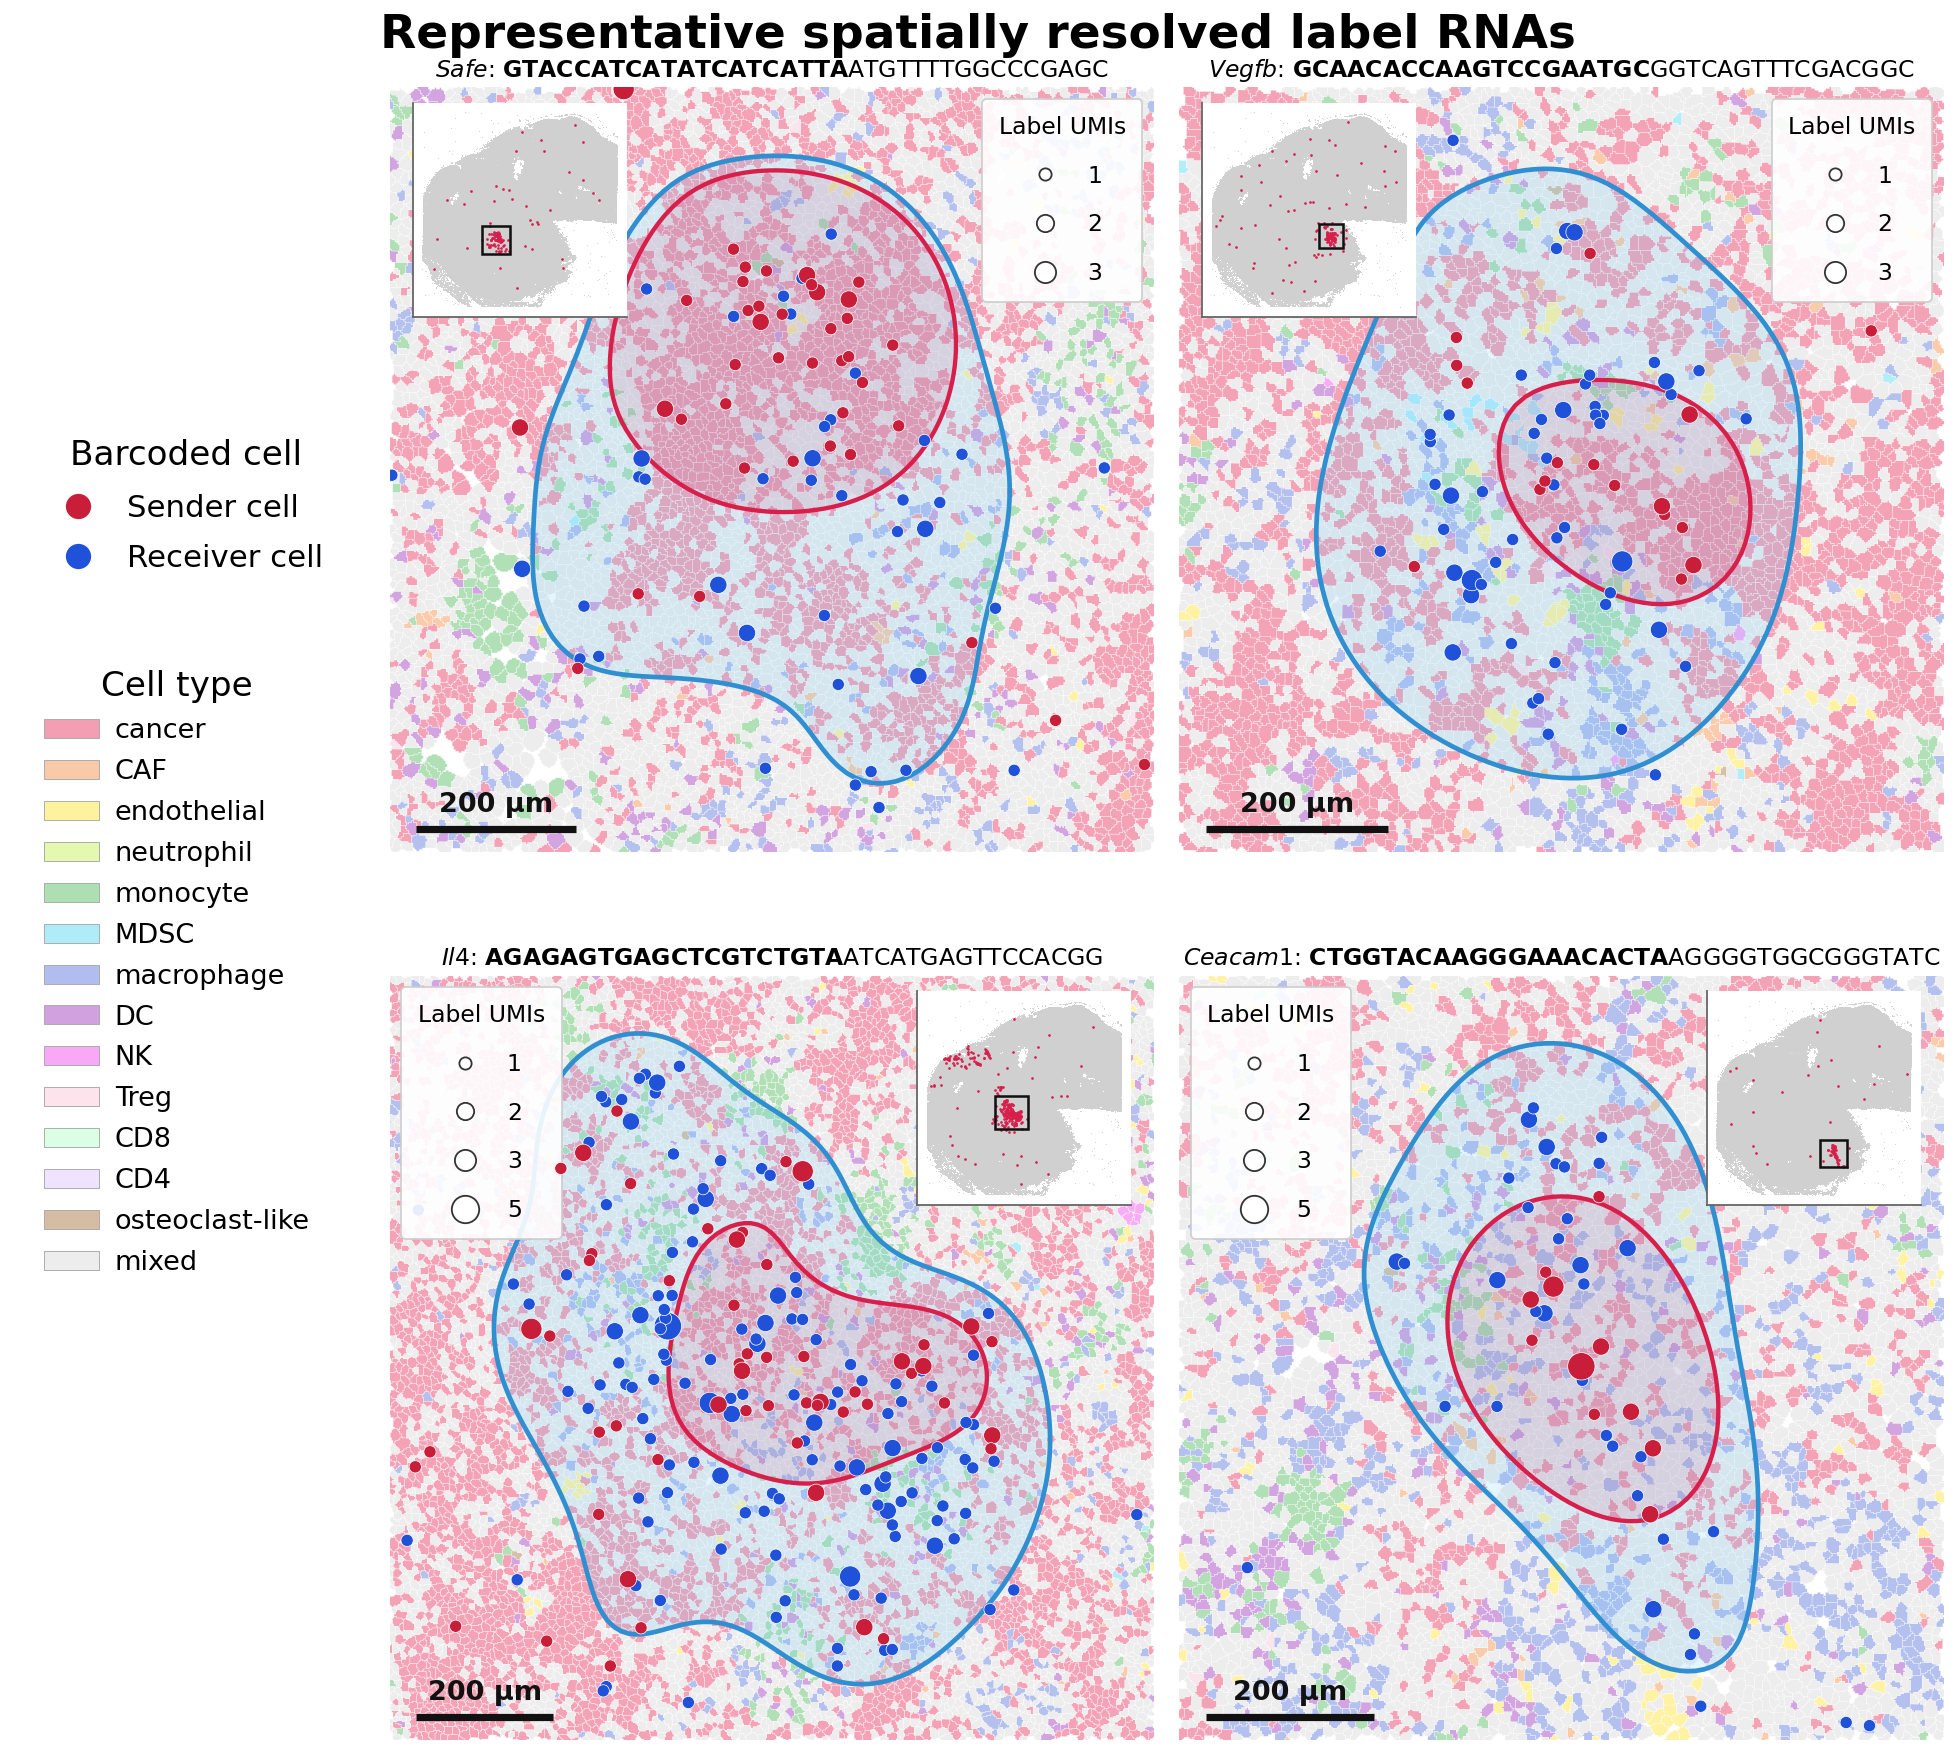

In [9]:
fig = plt.figure(figsize=(15, 14))
gs = fig.add_gridspec(2, 3, width_ratios=[0.46, 1, 1], wspace=0.04, hspace=0.13,
                      left=0.005, right=0.995, top=0.93, bottom=0.01)
axleg = fig.add_subplot(gs[:, 0]); axleg.axis('off')
panel_ax = [fig.add_subplot(gs[0, 1]), fig.add_subplot(gs[0, 2]),
            fig.add_subplot(gs[1, 1]), fig.add_subplot(gs[1, 2])]
for ax, (gene, idx, ic, sc) in zip(panel_ax, CLONES):
    seq = _lab[idx].split('_', 1)[1]
    draw_clone(ax, '1RR', idx, gene, seq, inset_corner=ic, size_corner=sc)

# shared legend column — barcoded-cell identity + the full cell-type vocabulary
bc_handles = [Line2D([0], [0], marker='o', lw=0, markerfacecolor=SENDER_DOT,
                     markeredgecolor='white', markersize=15, label='Sender cell'),
              Line2D([0], [0], marker='o', lw=0, markerfacecolor=RECEIVER_DOT,
                     markeredgecolor='white', markersize=15, label='Receiver cell')]
_pal = json.loads((CD / 'meta.json').read_text())['palette']
_vocab = ['cancer', 'CAF', 'endothelial', 'neutrophil', 'monocyte', 'MDSC', 'macrophage',
          'DC', 'NK', 'Treg', 'CD8', 'CD4', 'osteoclast-like', 'mixed']
def _sw(name):
    if name == 'mixed':
        return '#ededed'
    key = 'chemokine' if name == 'osteoclast-like' else name
    return _pastel(_pal.get(key, '#cfcfcf'))
ct_handles = [Patch(facecolor=_sw(v), edgecolor='#a8a8a8', linewidth=0.5, label=v) for v in _vocab]
leg1 = axleg.legend(handles=bc_handles, loc='upper left', bbox_to_anchor=(0.02, 0.80),
                    title='Barcoded cell', frameon=False, fontsize=17, title_fontsize=19,
                    labelspacing=0.7, handletextpad=0.6)
axleg.add_artist(leg1)
axleg.legend(handles=ct_handles, loc='upper left', bbox_to_anchor=(0.02, 0.66),
             title='Cell type', frameon=False, fontsize=15, title_fontsize=19,
             labelspacing=0.55, handletextpad=0.6)
fig.suptitle('Representative spatially resolved label RNAs', fontsize=26, fontweight='bold', y=0.965)
print('composited', len(CLONES), 'representative clones')


---
Barcode transfer is a short-range, exponential process: the per-cell transfer
probability halves within a few tens of microns of a cancer sender, sits far above
the shuffled null near the source, and returns to background by ~300 µm.
